/var/folders/2p/kflty7m55r712qwdgfdky9h80000gn/T/ipykernel_34737/3142214766.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


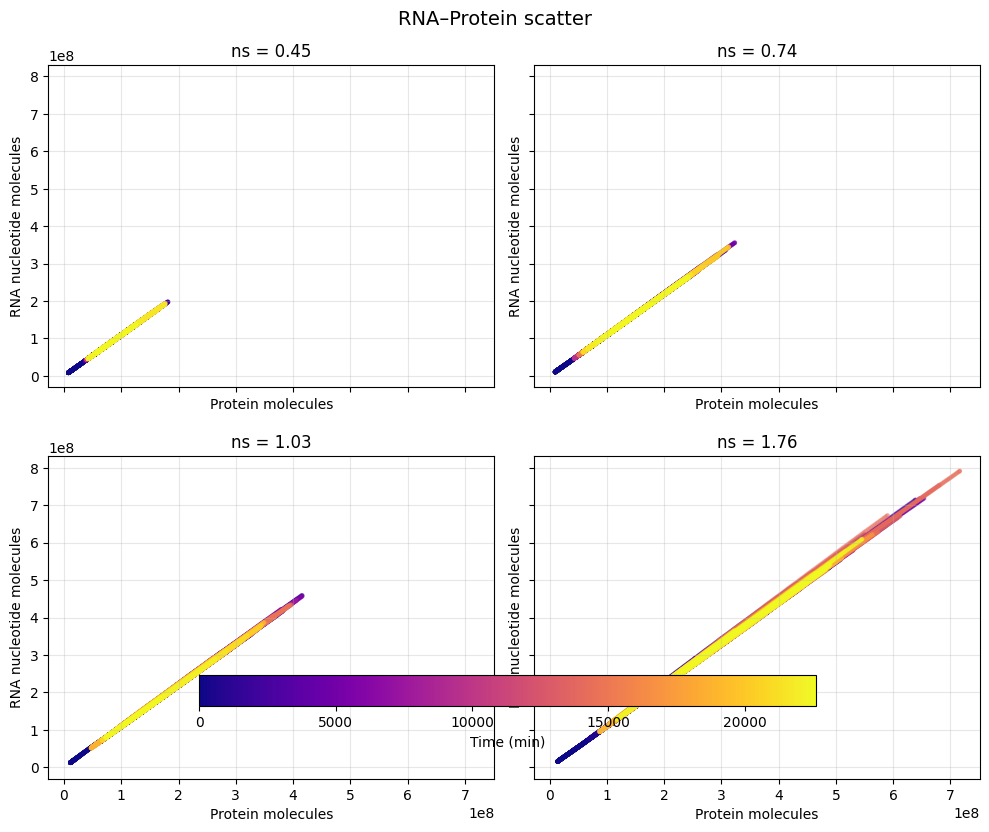

In [ ]:
# ============================================================
# UPDATED RNA–Protein scatter
# (new mass definitions, old visual semantics)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------
FILES = [
    ("Data/ns045.arrow", 0.45),
    ("Data/ns074.arrow", 0.74),
    ("Data/ns103.arrow", 1.03),
    ("Data/ns176.arrow", 1.76),
]

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
BURN_IN = 0 #1000.0

MRNA_LENGTHS_AA = {
    "mm": NX,
    "mt": NX,
    "mq": NX,
    "mr": NR,
}

RIBO_RNA_NT = 4565

# ------------------------------------------------------------
# Load Arrow
# ------------------------------------------------------------
def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return ipc.open_file(source).read_all().to_pandas()

# ------------------------------------------------------------
# Protein mass (unchanged logic)
# ------------------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo

def compute_protein(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()


    return (r + q + et + em)

# ------------------------------------------------------------
# RNA nucleotide mass (new, correct)
# ------------------------------------------------------------
def compute_RNA_nt(df):

    mm_tot = df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]
    mt_tot = df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]
    mq_tot = df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]
    mr_tot = df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]

    mRNA_mass = (
        mm_tot * (3 * MRNA_LENGTHS_AA["mm"]) +
        mt_tot * (3 * MRNA_LENGTHS_AA["mt"]) +
        mq_tot * (3 * MRNA_LENGTHS_AA["mq"]) +
        mr_tot * (3 * MRNA_LENGTHS_AA["mr"])
    ).to_numpy()

    r_tot = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_mass = r_tot * RIBO_RNA_NT

    return mRNA_mass + rRNA_mass

# ------------------------------------------------------------
# Plot setup
# ------------------------------------------------------------
cmap = plt.cm.plasma
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
for (filename, ns), ax in zip(FILES, axes):

    df = read_arrow(filename)

    # Burn-in
    t = df["timestamp"].values
    df = df.loc[t >= BURN_IN].reset_index(drop=True)
    t = df["timestamp"].values

    # Compute masses
    mass = compute_mass(df)
    PROT = compute_protein(df) #/mass
    RNA  = compute_RNA_nt(df) #/mass

    # Colour by time
    t_norm = (t - t.min()) / (t.max() - t.min() + 1e-12)
    colors = cmap(t_norm)

    ax.scatter(
        PROT,
        RNA,
        s=6,
        alpha=0.4,
        c=colors
    )

    ax.set_title(f"ns = {ns:.2f}")
    ax.set_xlabel("Protein molecules")
    ax.set_ylabel("RNA nucleotide molecules")
    ax.grid(alpha=0.3)

# ------------------------------------------------------------
# Shared colourbar
# ------------------------------------------------------------
norm = plt.Normalize(vmin=BURN_IN, vmax=t.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm, ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)
cbar.set_label("Time (min)")

fig.suptitle(
    f"RNA–Protein scatter",
    fontsize=14
)

plt.tight_layout()
plt.show()
